# Machine Learning-Based Forest Fire Burned Area Prediction System

# Feature Engineering

## Objective

The objective of this notebook is to create meaningful features from the original wildfire dataset.

Rather than relying solely on the raw variables, new features are engineered using domain knowledge and statistical transformations to improve predictive performance and interpretability.

The feature engineering process includes:

- Creating seasonal features
- Creating weekday/weekend features
- Engineering wildfire risk indicators
- Constructing weather interaction features
- Creating binary indicator variables
- Preparing the dataset for model training

## Load Clean Dataset

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width",1000)

print("Libraries imported successfully.")

Libraries imported successfully.


In [8]:
df = pd.read_csv("../../dataset/forestfires.csv")

df = df.drop_duplicates()

print(df.shape)

df.head()

(513, 13)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## Create Season Feature

In [9]:
season_map = {
    "dec":"Winter",
    "jan":"Winter",
    "feb":"Winter",

    "mar":"Spring",
    "apr":"Spring",
    "may":"Spring",

    "jun":"Summer",
    "jul":"Summer",
    "aug":"Summer",

    "sep":"Autumn",
    "oct":"Autumn",
    "nov":"Autumn"
}

df["season"] = df["month"].map(season_map)

In [10]:
df[["month","season"]].head(15)

,month,season
0,mar,Spring
1,oct,Autumn
2,oct,Autumn
3,mar,Spring
4,mar,Spring
5,aug,Summer
6,aug,Summer
7,aug,Summer
8,sep,Autumn
9,sep,Autumn


## Interpretation

The month variable was transformed into a seasonal feature.

Grouping months into seasons enables machine learning algorithms to capture broader climatic patterns instead of treating each month independently.

Seasonal information is expected to improve wildfire prediction because vegetation dryness and weather conditions vary across seasons.

## Weekend Feature

In [5]:
weekend = ["sat","sun"]

df["is_weekend"] = df["day"].isin(weekend).astype(int)

In [6]:
df[["day","is_weekend"]].head(20)

,day,is_weekend
0,fri,0
1,tue,0
2,sat,1
3,fri,0
4,sun,1
5,sun,1
6,mon,0
7,mon,0
8,tue,0
9,sat,1


## Interpretation

A binary weekend indicator was created.

Weekend observations were assigned the value 1, while weekdays were assigned 0.

This feature may capture behavioural differences in wildfire occurrence associated with increased recreational activities during weekends.

## Rain Indicator

In [12]:
df["rain_present"] = (df["rain"] > 0).astype(int)

In [13]:
df[["rain","rain_present"]].head(20)

,rain,rain_present
0,0.0,0
1,0.0,0
2,0.0,0
3,0.2,1
4,0.0,0
5,0.0,0
6,0.0,0
7,0.0,0
8,0.0,0
9,0.0,0


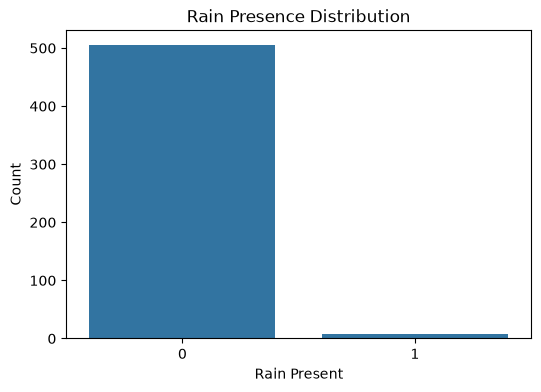

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="rain_present", data=df)

plt.title("Rain Presence Distribution")
plt.xlabel("Rain Present")
plt.ylabel("Count")

plt.show()

## Fire Weather Score

In [15]:
df["fire_weather_score"] = (
    df["FFMC"] +
    df["DMC"] +
    df["DC"] +
    df["ISI"]
)

In [16]:
df[["FFMC", "DMC", "DC", "ISI", "fire_weather_score"]].head()

,FFMC,DMC,DC,ISI,fire_weather_score
0,86.2,26.2,94.3,5.1,211.8
1,90.6,35.4,669.1,6.7,801.8
2,90.6,43.7,686.9,6.7,827.9
3,91.7,33.3,77.5,9.0,211.5
4,89.3,51.3,102.2,9.6,252.4


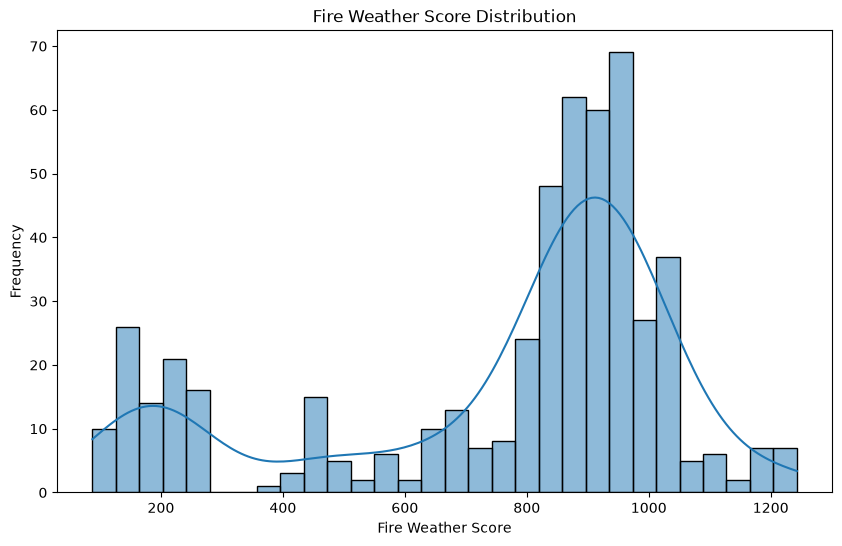

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df["fire_weather_score"], bins=30, kde=True)

plt.title("Fire Weather Score Distribution")
plt.xlabel("Fire Weather Score")
plt.ylabel("Frequency")

plt.show()

## Interpretation

The engineered Fire Weather Score combines the four Canadian Fire Weather Index (FWI) components into a single composite feature.

The distribution shows that most observations have relatively high fire weather scores, indicating conditions favourable for wildfire ignition and spread.

A smaller group of observations exhibits much lower scores, suggesting less severe fire-weather conditions.

This engineered feature captures overall wildfire danger more effectively than using each FWI component independently and is expected to improve the learning capability of machine learning models.

### Dryness Index

In [19]:
df["dryness_index"] = df["temp"] / (df["RH"] + 1)

In [20]:
df[["temp", "RH", "dryness_index"]].head()

,temp,RH,dryness_index
0,8.2,51,0.157692
1,18.0,33,0.529412
2,14.6,33,0.429412
3,8.3,97,0.084694
4,11.4,99,0.114000


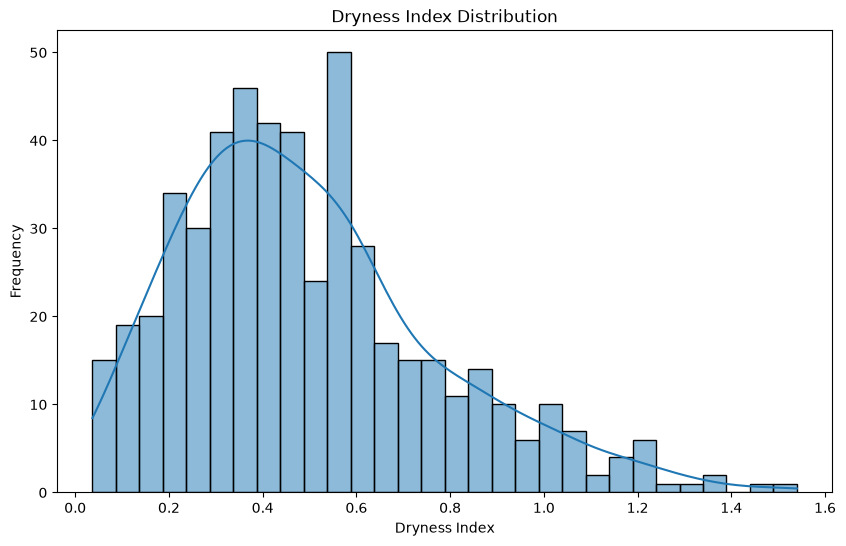

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(df["dryness_index"],
             bins=30,
             kde=True)

plt.title("Dryness Index Distribution")
plt.xlabel("Dryness Index")
plt.ylabel("Frequency")

plt.show()

## Interpretation

The Dryness Index combines air temperature and relative humidity into a single indicator of environmental dryness.

Most observations are concentrated at moderate dryness levels, while only a small number represent extremely dry atmospheric conditions.

Higher Dryness Index values indicate hotter and drier environments, which are generally associated with an increased likelihood of wildfire ignition and rapid fire spread.

This engineered feature captures an important interaction between temperature and humidity and is expected to provide additional predictive information for machine learning models.

### Wind Effect

In [22]:
df["wind_effect"] = df["wind"] * df["temp"]

In [23]:
df[["temp", "wind", "wind_effect"]].head()

,temp,wind,wind_effect
0,8.2,6.7,54.94
1,18.0,0.9,16.20
2,14.6,1.3,18.98
3,8.3,4.0,33.20
4,11.4,1.8,20.52


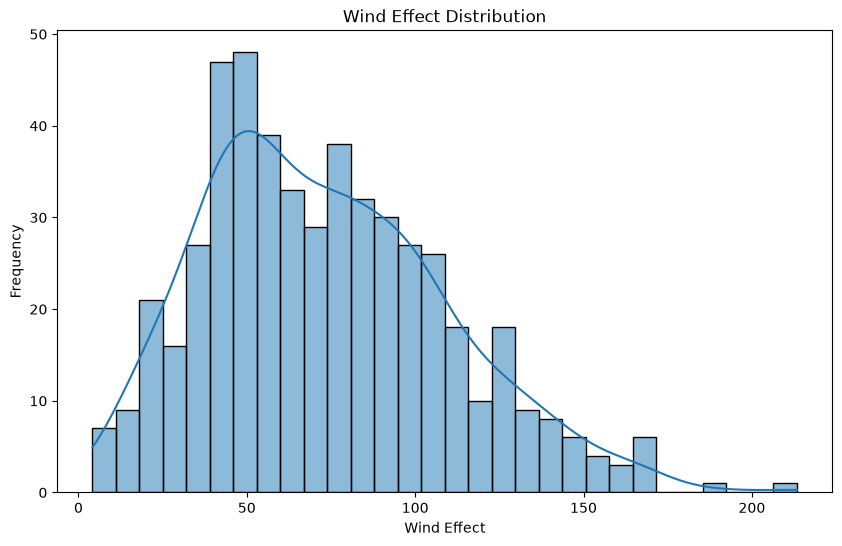

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(df["wind_effect"],
             bins=30,
             kde=True)

plt.title("Wind Effect Distribution")
plt.xlabel("Wind Effect")
plt.ylabel("Frequency")

plt.show()

## Interpretation

The Wind Effect feature combines air temperature and wind speed into a single interaction variable representing conditions that favour rapid wildfire spread.

Most observations are concentrated at moderate Wind Effect values, while a smaller number correspond to extreme combinations of high temperature and strong winds.

Higher Wind Effect values indicate weather conditions that may increase wildfire intensity and accelerate fire propagation.

This engineered interaction feature captures complex relationships between temperature and wind that may improve the predictive performance of machine learning models.

## Fuel Moisture Deficit

In [25]:
df["fuel_moisture_deficit"] = df["DMC"] / (df["RH"] + 1)

In [26]:
df[["DMC", "RH", "fuel_moisture_deficit"]].head()

,DMC,RH,fuel_moisture_deficit
0,26.2,51,0.503846
1,35.4,33,1.041176
2,43.7,33,1.285294
3,33.3,97,0.339796
4,51.3,99,0.513000


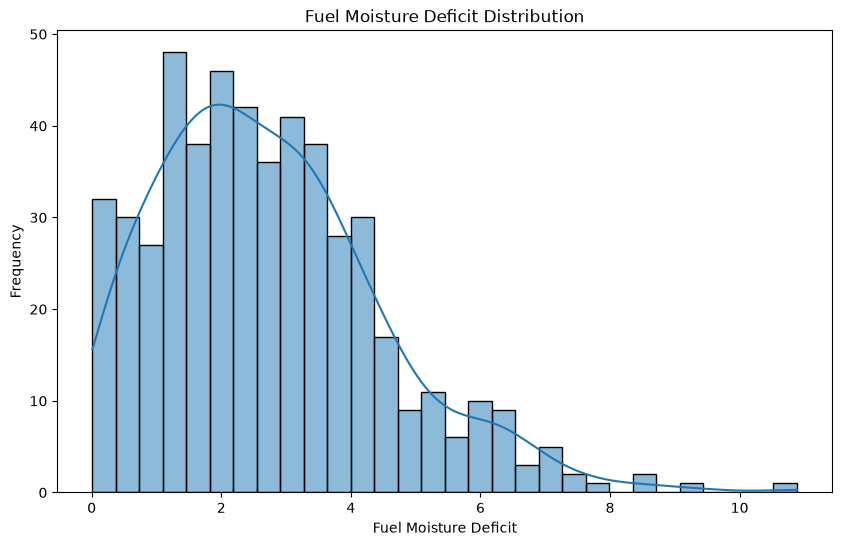

In [27]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["fuel_moisture_deficit"],
    bins=30,
    kde=True
)

plt.title("Fuel Moisture Deficit Distribution")
plt.xlabel("Fuel Moisture Deficit")
plt.ylabel("Frequency")

plt.show()

## Interpretation

The Fuel Moisture Deficit feature combines the Duff Moisture Code (DMC) with relative humidity to estimate the overall dryness of forest fuels.

Most observations fall within moderate fuel moisture deficit values, while a smaller number represent extremely dry fuel conditions.

Higher values indicate drier forest fuels together with lower atmospheric moisture, increasing the potential for wildfire ignition and sustained fire spread.

This engineered feature provides a more informative representation of fuel dryness than using DMC or relative humidity independently and is expected to improve machine learning performance.

## Cyclical Encoding of Month

In [28]:
month_map = {
    "jan":1,
    "feb":2,
    "mar":3,
    "apr":4,
    "may":5,
    "jun":6,
    "jul":7,
    "aug":8,
    "sep":9,
    "oct":10,
    "nov":11,
    "dec":12
}

df["month_num"] = df["month"].map(month_map)

In [29]:
df[["month","month_num"]].head()

,month,month_num
0,mar,3
1,oct,10
2,oct,10
3,mar,3
4,mar,3


In [30]:
import numpy as np

df["month_sin"] = np.sin(
    2 * np.pi * df["month_num"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month_num"] / 12
)

In [31]:
df[
    [
        "month",
        "month_num",
        "month_sin",
        "month_cos"
    ]
].head(12)

,month,month_num,month_sin,month_cos
0,mar,3,1.000000,6.123234e-17
1,oct,10,-0.866025,5.000000e-01
2,oct,10,-0.866025,5.000000e-01
3,mar,3,1.000000,6.123234e-17
4,mar,3,1.000000,6.123234e-17
5,aug,8,-0.866025,-5.000000e-01
6,aug,8,-0.866025,-5.000000e-01
7,aug,8,-0.866025,-5.000000e-01
8,sep,9,-1.000000,-1.836970e-16
9,sep,9,-1.000000,-1.836970e-16


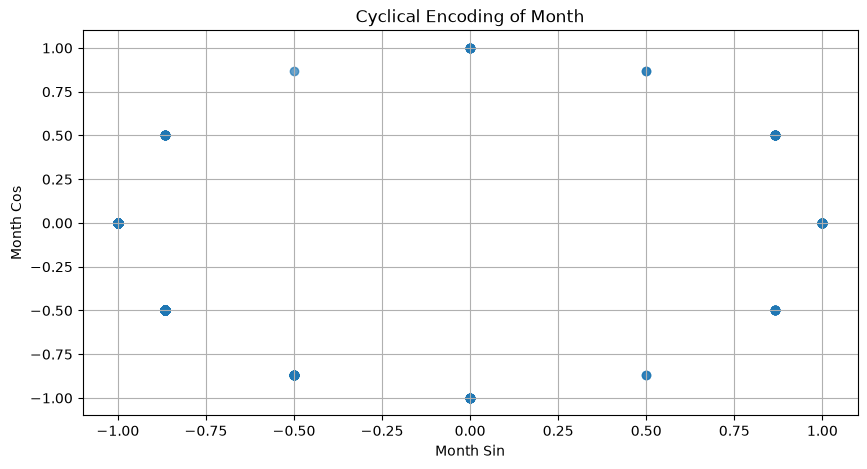

In [32]:
plt.figure(figsize=(10,5))

plt.scatter(
    df["month_sin"],
    df["month_cos"],
    alpha=0.7
)

plt.title("Cyclical Encoding of Month")
plt.xlabel("Month Sin")
plt.ylabel("Month Cos")

plt.grid(True)

plt.show()

## Interpretation

The month variable was transformed into cyclical sine and cosine features to preserve its seasonal nature.

Unlike simple numerical encoding, cyclical encoding correctly represents December and January as adjacent months rather than treating them as being far apart.

The scatter plot forms a circular pattern, confirming that the transformation successfully captures the continuous yearly cycle.

These engineered features enable machine learning models to learn seasonal wildfire behaviour more effectively.

## Day of Week Cyclical Encoding

In [33]:
day_map = {
    "mon": 1,
    "tue": 2,
    "wed": 3,
    "thu": 4,
    "fri": 5,
    "sat": 6,
    "sun": 7
}

df["day_num"] = df["day"].map(day_map)

In [34]:
df[["day", "day_num"]].head(12)

,day,day_num
0,fri,5
1,tue,2
2,sat,6
3,fri,5
4,sun,7
5,sun,7
6,mon,1
7,mon,1
8,tue,2
9,sat,6


In [35]:
import numpy as np

df["day_sin"] = np.sin(
    2 * np.pi * df["day_num"] / 7
)

df["day_cos"] = np.cos(
    2 * np.pi * df["day_num"] / 7
)

In [36]:
df[
    [
        "day",
        "day_num",
        "day_sin",
        "day_cos"
    ]
].head(15)

,day,day_num,day_sin,day_cos
0,fri,5,-9.749279e-01,-0.222521
1,tue,2,9.749279e-01,-0.222521
2,sat,6,-7.818315e-01,0.623490
3,fri,5,-9.749279e-01,-0.222521
4,sun,7,-2.449294e-16,1.000000
5,sun,7,-2.449294e-16,1.000000
6,mon,1,7.818315e-01,0.623490
7,mon,1,7.818315e-01,0.623490
8,tue,2,9.749279e-01,-0.222521
9,sat,6,-7.818315e-01,0.623490


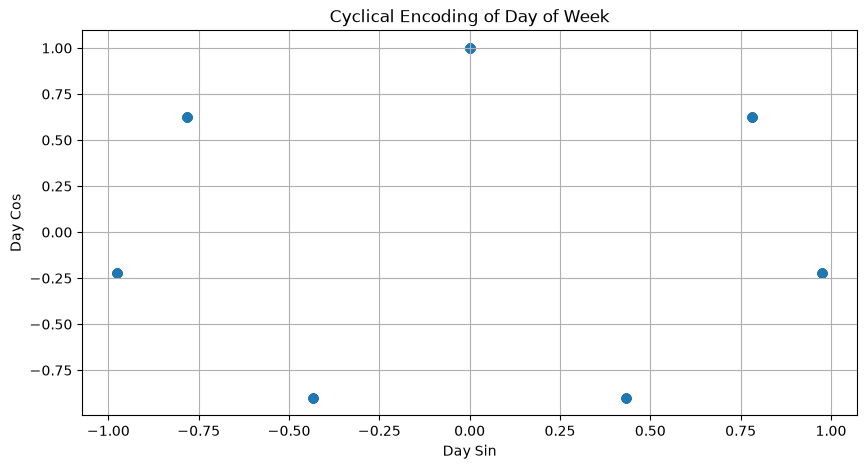

In [37]:
plt.figure(figsize=(10,5))

plt.scatter(
    df["day_sin"],
    df["day_cos"],
    alpha=0.7
)

plt.title("Cyclical Encoding of Day of Week")

plt.xlabel("Day Sin")

plt.ylabel("Day Cos")

plt.grid(True)

plt.show()

## Interpretation

The day-of-week variable was transformed into sine and cosine components to preserve its cyclical nature.

Unlike simple numerical encoding, cyclical encoding represents Sunday and Monday as neighbouring days instead of treating them as numerically far apart.

The circular arrangement of the transformed values confirms that the weekly cycle has been successfully preserved.

These engineered features allow machine learning models to better capture temporal wildfire patterns associated with different days of the week.

## Spatial Feature Engineering Using K-Means Clustering

In [38]:
from sklearn.cluster import KMeans

In [39]:
coords = df[["X", "Y"]]
coords.head()

,X,Y
0,7,5
1,7,4
2,7,4
3,8,6
4,8,6


### Find the Best Number of Clusters (Elbow Method)

In [40]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(coords)

    inertia.append(kmeans.inertia_)

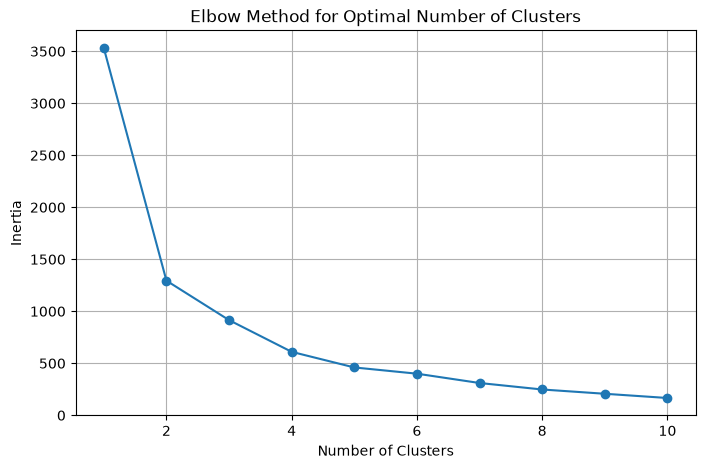

In [41]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

## Create Spatial Clusters

### Fit the Final K-Means Model

In [42]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["location_cluster"] = kmeans.fit_predict(coords)

### View the Cluster Assignments

In [43]:
df[
    ["X", "Y", "location_cluster"]
].head(20)

,X,Y,location_cluster
0,7,5,2
1,7,4,2
2,7,4,2
3,8,6,0
4,8,6,0
5,8,6,0
6,8,6,0
7,8,6,0
8,8,6,0
9,7,5,2


### Count Fires in Each Cluster

In [44]:
df["location_cluster"].value_counts().sort_index()

location_cluster
0     72
1    122
2    148
3    171
Name: count, dtype: int64

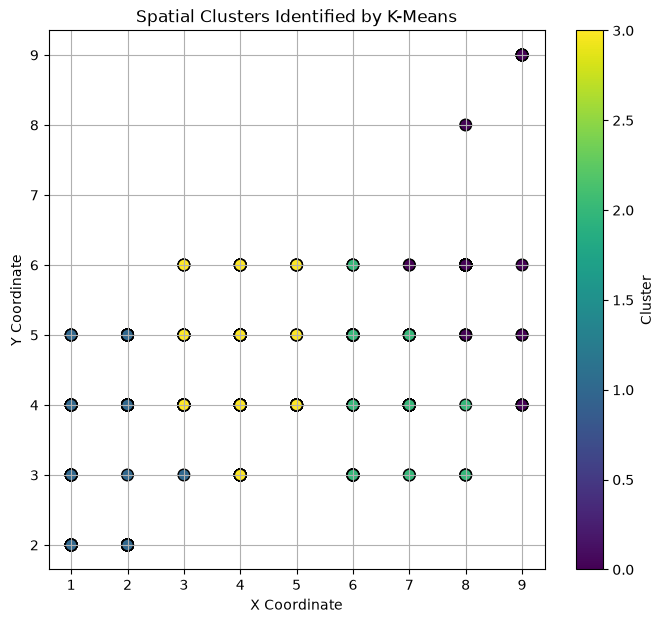

In [45]:
plt.figure(figsize=(8,7))

scatter = plt.scatter(
    df["X"],
    df["Y"],
    c=df["location_cluster"],
    cmap="viridis",
    s=70,
    edgecolor="black"
)

plt.colorbar(scatter, label="Cluster")

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.title("Spatial Clusters Identified by K-Means")

plt.grid(True)

plt.show()